<h1 align="center">ASSIGNMENT 02 — APPLICATION 3: E-COMMERCE REVIEWS ANALYSIS</h1>

# 1. Problem Definition (Section 10.1 - Assignment 02)

- **Bối cảnh thực tế**: Trong kỷ nguyên bán lẻ trực tuyến, phân tích hành vi và thấu hiểu mối quan tâm của khách hàng qua phản hồi văn bản (Customer Reviews) đóng vai trò quyết định trong việc tối ưu hóa chuỗi cung ứng, cá nhân hóa gợi ý sản phẩm và nâng cao tỷ lệ giữ chân khách hàng (Customer Retention).
- **Mục tiêu hệ thống**: Xây dựng Hệ thống Thông minh giải quyết bài toán Phân loại (Supervised Classification) kết hợp Xử lý Ngôn ngữ Tự nhiên (NLP) nhằm dự đoán xu hướng hài lòng và khuyến nghị mua sắm của khách hàng (`Recommended IND`) dựa trên phản hồi dạng văn bản (`Review Text`), độ tuổi và nhóm ngành hàng thời trang.
- **Hình thức hóa toán học**:
  - Không gian đầu vào: Kết hợp dữ liệu văn bản đã vector hóa và đặc trưng hành vi:
    $$x_i = [x_{\text{text\_tfidf}}, x_{\text{behavioral}}]^T \in \mathbb{R}^d$$
  - Đầu ra mục tiêu: Nhãn hành vi/sở thích nhị phân:
    $$y_i \in \{0, 1\} \quad (0: \text{Not Recommended / Churn Risk}, 1: \text{Recommended / High Interest})$$
  - Hàm giả thuyết: $f_\theta: \mathbb{R}^d \rightarrow [0, 1]$ dự đoán xác suất $P(y=1|x)$, tối ưu hóa hàm mất mát nhị phân Binary Cross-Entropy (Log-Loss).
- **So sánh với Application 1 & 2**:
  - *Diabetes (Classification)*: Thuần túy là bảng số liệu lâm sàng có cấu trúc (Tabular clinical data).
  - *House Price (Regression)*: Dự đoán giá trị số thực liên tục không âm ($y \in \mathbb{R}^+$), tối ưu hóa hàm mất mát MSE.
  - *E-Commerce (Text + Tabular Classification)*: Xử lý dữ liệu phi cấu trúc (Unstructured Text), đòi hỏi kỹ thuật vector hóa từ vựng (Word Embedding / TF-IDF) và đối mặt với hiện tượng mất cân bằng lớp tự nhiên (Class Imbalance).

# 2. Dataset Source (Section 10.2 - Assignment 02)

- **Tên Dataset**: Women's E-Commerce Clothing Reviews
- **Nguồn Kaggle**: https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
- **Kích thước mẫu ban đầu**: 23,486 bản ghi phản hồi thực tế của khách hàng.
- **Số lượng đặc trưng**: 10 cột dữ liệu (bao gồm mã định danh quần áo `Clothing ID`, độ tuổi `Age`, tiêu đề `Title`, nội dung `Review Text`, số sao `Rating`, chỉ số khuyên dùng `Recommended IND`, số lượt tương tác hữu ích `Positive Feedback Count`, và 3 cấp phân loại danh mục sản phẩm `Division`, `Department`, `Class`).
- **Mô tả 1 quan sát (One Observation)**: Một lượt trải nghiệm và đánh giá của một khách hàng nữ đối với một sản phẩm thời trang cụ thể, phản ánh cảm xúc, độ vừa vặn, chất liệu vải và quyết định có khuyến nghị sản phẩm này cho người khác hay không.

In [1]:
# Setup môi trường và nạp các thư viện Machine Learning & NLP
import warnings
import time
import re
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

print("Môi trường Machine Learning và NLP cho E-Commerce Customer Behavior đã sẵn sàng!")

Môi trường Machine Learning và NLP cho E-Commerce Customer Behavior đã sẵn sàng!


# 3. Dataset Loading (Section 10.2 & 10.3 - Assignment 02)
Nạp dữ liệu từ file `Womens Clothing E-Commerce Reviews.csv` vào cấu trúc Pandas DataFrame.

In [2]:
DATA_PATH = "C:/Users/ADMIN/Downloads/Womens Clothing E-Commerce Reviews.csv/Womens Clothing E-Commerce Reviews.csv"
df = pd.read_csv(DATA_PATH)

# Xóa cột Unnamed: 0 nếu tồn tại (chỉ là cột chỉ số cũ khi xuất file)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Nạp dữ liệu thành công! Kích thước ban đầu (df.shape): {df.shape}")

Nạp dữ liệu thành công! Kích thước ban đầu (df.shape): (23486, 10)


# 4. Dataset Inspection (Section 10.3 & Part II - Assignment 02)
Kiểm tra cấu trúc ban đầu: Số dòng ($N = 23,486$), số cột thuộc tính (10 cột), 5 dòng đầu tiên, kiểu dữ liệu (`df.info()`) và bảng tóm tắt phân phối số học (`df.describe()`).

In [4]:
print(f"Tổng số bản ghi giao dịch/đánh giá (N): {df.shape[0]}")
print(f"Tổng số cột thuộc tính: {df.shape[1]}")

print("\n--- 5 dòng đầu tiên ---")
display(df.head())

print("\n--- Kiểu dữ liệu từng thuộc tính ---")
df.info()

print("\n--- Bảng thống kê mô tả phân phối các biến số học ---")
display(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

Tổng số bản ghi giao dịch/đánh giá (N): 23486
Tổng số cột thuộc tính: 10

--- 5 dòng đầu tiên ---


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses



--- Kiểu dữ liệu từng thuộc tính ---
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 9.3 MB

--- Bảng thống kê mô tả phân phối các biến số học ---


,count,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,918.118709,203.298980,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


# 5. Data-Quality Analysis (Section 10.4 - Assignment 02)
Kiểm kê chất lượng dữ liệu tổng thể: Đánh giá phân phối biến mục tiêu `Recommended IND` và tỷ lệ mất cân bằng dữ liệu (Class Imbalance).

In [5]:
print("=== 5. KIỂM KÊ CHẤT LƯỢNG DỮ LIỆU TỔNG THỂ ===")
total_reviews = len(df)
pos_count = (df['Recommended IND'] == 1).sum()
neg_count = (df['Recommended IND'] == 0).sum()
pos_ratio = (pos_count / total_reviews) * 100

print(f"- Tổng số quan sát: {total_reviews}")
print(f"- Lớp tích cực (Recommended = 1): {pos_count} ({pos_ratio:.2f}%)")
print(f"- Lớp tiêu cực (Not Recommended = 0): {neg_count} ({100 - pos_ratio:.2f}%)")
print(f"- Tỷ lệ mất cân bằng (Imbalance Ratio): xấp xỉ {pos_count / neg_count:.1f} : 1")
print("-> Nhận xét: Dữ liệu mất cân bằng mạnh. Cần sử dụng F1-Score, ROC-AUC và kỹ thuật 'class_weight=balanced' thay vì chỉ dùng Accuracy.")

=== 5. KIỂM KÊ CHẤT LƯỢNG DỮ LIỆU TỔNG THỂ ===
- Tổng số quan sát: 23486
- Lớp tích cực (Recommended = 1): 19314 (82.24%)
- Lớp tiêu cực (Not Recommended = 0): 4172 (17.76%)
- Tỷ lệ mất cân bằng (Imbalance Ratio): xấp xỉ 4.6 : 1
-> Nhận xét: Dữ liệu mất cân bằng mạnh. Cần sử dụng F1-Score, ROC-AUC và kỹ thuật 'class_weight=balanced' thay vì chỉ dùng Accuracy.


# 6. Missing-Value Analysis (Section 10.4 - Assignment 02)
Kiểm tra sự tồn tại của các giá trị khuyết thiếu hiển thị trực tiếp (`NaN` / `null`) trên toàn bộ 10 thuộc tính.

In [6]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_report = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percent': missing_pct})

print("=== KIỂM KÊ GIÁ TRỊ KHUYẾT THIẾU (NaN) ===")
display(missing_report[missing_report['Missing_Count'] > 0])

print("""
Giải thích hướng xử lý nghiệp vụ:
1. `Title`: Khuyết 3,810 dòng (~16.2%). Đây là hành vi thực tế khi khách hàng bỏ qua tiêu đề và viết thẳng vào phần nội dung. Ta sẽ điền chuỗi rỗng ("") trước khi gộp văn bản.
2. `Review Text`: Khuyết 845 dòng (~3.6%), do khách hàng chỉ chấm sao mà không viết nhận xét. Ta cũng sẽ xử lý điền rỗng để bảo toàn số lượng mẫu hành vi.
3. `Division Name`, `Department Name`, `Class Name`: Cùng khuyết 14 dòng (~0.06%), tỷ lệ cực nhỏ sẽ được điền bằng nhãn 'Missing' qua Pipeline.
""")

=== KIỂM KÊ GIÁ TRỊ KHUYẾT THIẾU (NaN) ===


,Missing_Count,Missing_Percent
Title,3810,16.222430
Review Text,845,3.597888
Division Name,14,0.059610
Department Name,14,0.059610
Class Name,14,0.059610



Giải thích hướng xử lý nghiệp vụ:
1. `Title`: Khuyết 3,810 dòng (~16.2%). Đây là hành vi thực tế khi khách hàng bỏ qua tiêu đề và viết thẳng vào phần nội dung. Ta sẽ điền chuỗi rỗng ("") trước khi gộp văn bản.
2. `Review Text`: Khuyết 845 dòng (~3.6%), do khách hàng chỉ chấm sao mà không viết nhận xét. Ta cũng sẽ xử lý điền rỗng để bảo toàn số lượng mẫu hành vi.
3. `Division Name`, `Department Name`, `Class Name`: Cùng khuyết 14 dòng (~0.06%), tỷ lệ cực nhỏ sẽ được điền bằng nhãn 'Missing' qua Pipeline.



# 7. Duplicate Analysis (Section 10.4 - Assignment 02)
Phân tích trùng lặp dữ liệu: Kiểm tra các dòng phản hồi bị ghi nhận trùng lặp hoàn toàn trên toàn bộ thuộc tính.

In [7]:
exact_duplicates = df.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp 100% tất cả các cột: {exact_duplicates} bản ghi.")

# Xử lý loại bỏ các bản ghi trùng lặp hoàn toàn để tránh thiên lệch khi huấn luyện
if exact_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"-> Đã loại bỏ thành công {exact_duplicates} bản ghi trùng. Kích thước dữ liệu sạch: {df.shape}")

Số lượng bản ghi trùng lặp 100% tất cả các cột: 21 bản ghi.
-> Đã loại bỏ thành công 21 bản ghi trùng. Kích thước dữ liệu sạch: (23465, 10)


# 8. Invalid-Value Analysis (Section 10.4 - Assignment 02)
Phát hiện các giá trị bất thường và không hợp lệ:
- Kiểm tra miền giá trị hợp lệ của `Age` ($18 \le \text{Age} \le 100$).
- Kiểm tra miền giá trị hợp lệ của `Rating` ($\in \{1, 2, 3, 4, 5\}$).
- Kiểm tra tính logic giữa `Rating` và `Recommended IND`.

In [8]:
print("=== 8. KIỂM TRA TÍNH HỢP LỆ DỮ LIỆU ===")
invalid_age = ((df['Age'] < 18) | (df['Age'] > 100)).sum()
invalid_rating = (~df['Rating'].isin([1, 2, 3, 4, 5])).sum()
invalid_rec = (~df['Recommended IND'].isin([0, 1])).sum()

print(f"- Số bản ghi có độ tuổi không hợp lệ: {invalid_age}")
print(f"- Số bản ghi có điểm đánh giá sao không hợp lệ: {invalid_rating}")
print(f"- Số bản ghi có chỉ số khuyên dùng không hợp lệ: {invalid_rec}")

# Kiểm tra tương quan giữa Rating và Recommended IND
print("\nTỷ lệ khách hàng khuyên dùng theo từng mức sao:")
display(df.groupby('Rating')['Recommended IND'].agg(['count', 'mean']).rename(columns={'mean': 'Recommendation_Rate'}))
print("-> Kết luận: Điểm sao tỉ lệ thuận hoàn hảo với khuyến nghị mua sắm (Sao 1-2 hầu như không khuyên dùng, sao 4-5 gần 100% khuyên dùng).")

=== 8. KIỂM TRA TÍNH HỢP LỆ DỮ LIỆU ===
- Số bản ghi có độ tuổi không hợp lệ: 0
- Số bản ghi có điểm đánh giá sao không hợp lệ: 0
- Số bản ghi có chỉ số khuyên dùng không hợp lệ: 0

Tỷ lệ khách hàng khuyên dùng theo từng mức sao:


,count,Recommendation_Rate
Rating,,
1,842,0.019002
2,1565,0.060064
3,2871,0.414141
4,5076,0.966903
5,13111,0.998093


-> Kết luận: Điểm sao tỉ lệ thuận hoàn hảo với khuyến nghị mua sắm (Sao 1-2 hầu như không khuyên dùng, sao 4-5 gần 100% khuyên dùng).


# 9. Outlier Analysis (Section 10.4 - Assignment 02)
Phân tích ngoại lệ thông qua phân vị và biểu đồ hộp Boxplot cho các thuộc tính số học: `Age`, `Positive Feedback Count` và đặc trưng phái sinh `Word_Count` (độ dài bình luận).

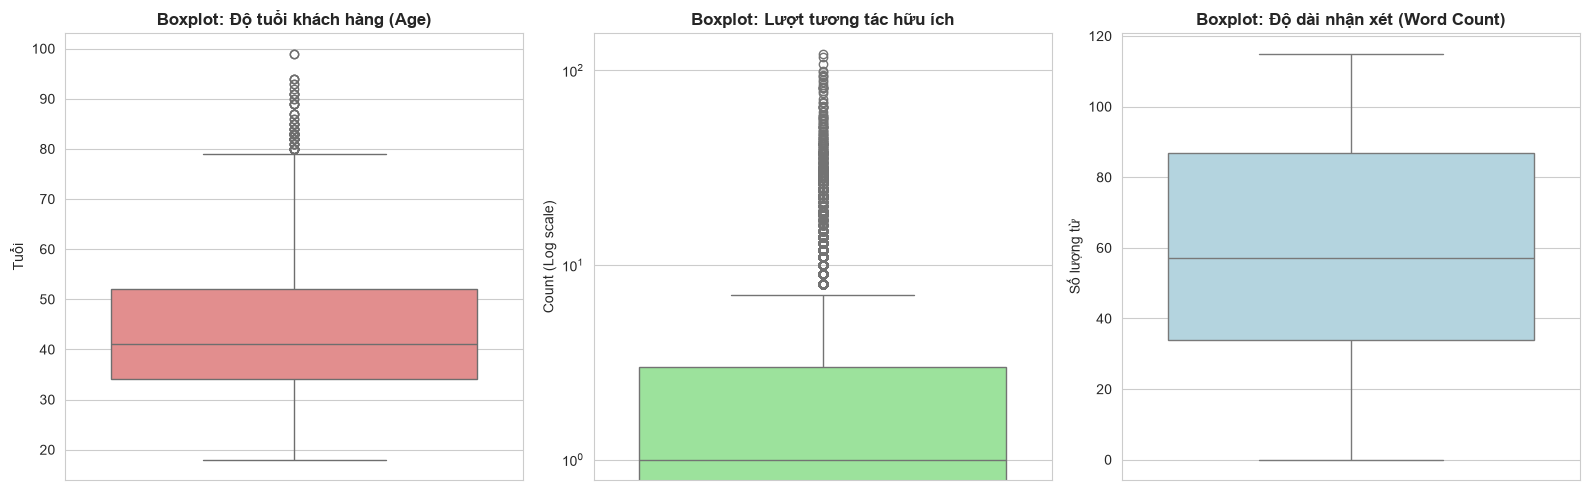

Nhận xét ngoại lệ: Biến 'Positive Feedback Count' có đuôi phân phối lệch phải rất dài (một số bình luận nhận được hàng chục lượt upvote từ cộng đồng). 'Word Count' bị chặn trên ở khoảng 115 từ do giới hạn ký tự form đánh giá của trang E-commerce.


In [9]:
# Trích xuất tạm thời độ dài từ của review để phân tích ngoại lệ
temp_word_count = df['Review Text'].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['Age'], ax=axes[0], color='lightcoral')
axes[0].set_title("Boxplot: Độ tuổi khách hàng (Age)", fontweight='bold')
axes[0].set_ylabel("Tuổi")

sns.boxplot(y=df['Positive Feedback Count'], ax=axes[1], color='lightgreen')
axes[1].set_title("Boxplot: Lượt tương tác hữu ích", fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_ylabel("Count (Log scale)")

sns.boxplot(y=temp_word_count, ax=axes[2], color='lightblue')
axes[2].set_title("Boxplot: Độ dài nhận xét (Word Count)", fontweight='bold')
axes[2].set_ylabel("Số lượng từ")

plt.tight_layout()
plt.savefig('ecommerce_outliers_boxplot.png', dpi=150)
plt.show()

print("Nhận xét ngoại lệ: Biến 'Positive Feedback Count' có đuôi phân phối lệch phải rất dài (một số bình luận nhận được hàng chục lượt upvote từ cộng đồng). 'Word Count' bị chặn trên ở khoảng 115 từ do giới hạn ký tự form đánh giá của trang E-commerce.")

# 10. Exploratory Data Analysis - EDA (Section 10.5 & Part V - Assignment 02)
Thực hiện trực quan hóa 3 khía cạnh phân phối cốt lõi của hành vi khách hàng thương mại điện tử. Mỗi biểu đồ đều đi kèm đầy đủ 3 phân tích học thuật: **Observation**, **Interpretation** và **ML Implication**.

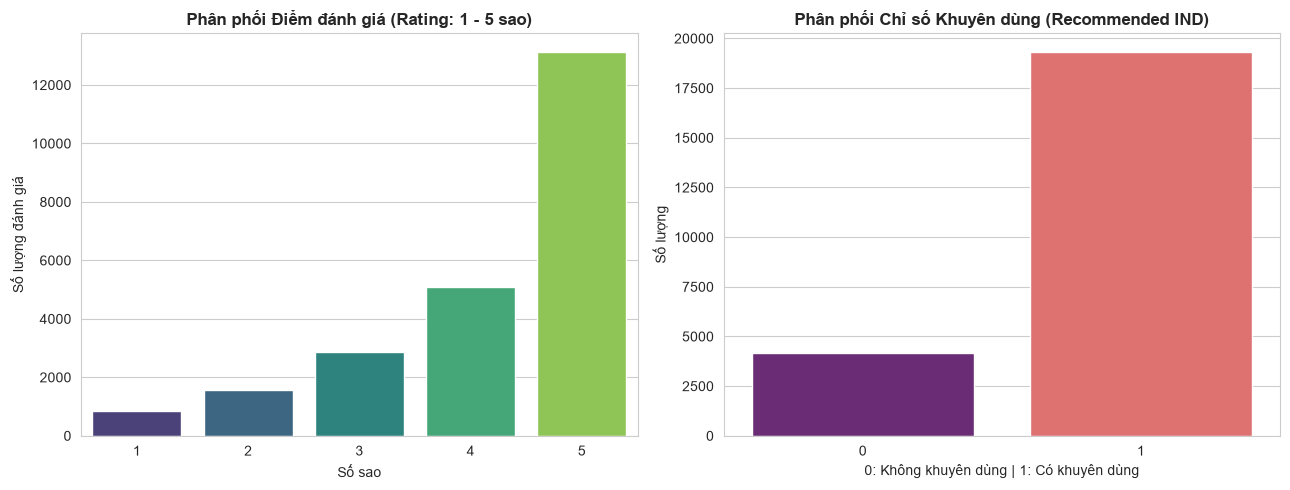


[Biểu đồ 1 Analysis]
- Observation: Phân phối đánh giá sao nghiêng mạnh về 5 sao (hơn 13,000 lượt). Tương ứng, nhãn Recommended chiếm hơn 82.2% toàn bộ tập dữ liệu.
- Interpretation: Khách hàng chỉ chủ động để lại phản hồi khi họ cực kỳ hài lòng (hoặc cực kỳ thất vọng), tạo ra hiện tượng phân cực nhưng thiên lệch lớn về phía tích cực.
- ML Implication: Nếu đánh giá bằng Accuracy, một mô hình ngây thơ luôn đoán nhãn 1 sẽ dễ dàng đạt 82.2% nhưng hoàn toàn vô dụng với việc phát hiện khách hàng thất vọng. Cần tối ưu F1-Score trên lớp 0 (thiểu số) và áp dụng class-weight balancing.



In [10]:
# ── Biểu đồ 1: Phân phối Đánh giá sao và Nhãn Khuyên dùng ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[0])
axes[0].set_title("Phân phối Điểm đánh giá (Rating: 1 - 5 sao)", fontweight='bold')
axes[0].set_xlabel("Số sao")
axes[0].set_ylabel("Số lượng đánh giá")

sns.countplot(data=df, x='Recommended IND', palette='magma', ax=axes[1])
axes[1].set_title("Phân phối Chỉ số Khuyên dùng (Recommended IND)", fontweight='bold')
axes[1].set_xlabel("0: Không khuyên dùng | 1: Có khuyên dùng")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

print("""
[Biểu đồ 1 Analysis]
- Observation: Phân phối đánh giá sao nghiêng mạnh về 5 sao (hơn 13,000 lượt). Tương ứng, nhãn Recommended chiếm hơn 82.2% toàn bộ tập dữ liệu.
- Interpretation: Khách hàng chỉ chủ động để lại phản hồi khi họ cực kỳ hài lòng (hoặc cực kỳ thất vọng), tạo ra hiện tượng phân cực nhưng thiên lệch lớn về phía tích cực.
- ML Implication: Nếu đánh giá bằng Accuracy, một mô hình ngây thơ luôn đoán nhãn 1 sẽ dễ dàng đạt 82.2% nhưng hoàn toàn vô dụng với việc phát hiện khách hàng thất vọng. Cần tối ưu F1-Score trên lớp 0 (thiểu số) và áp dụng class-weight balancing.
""")

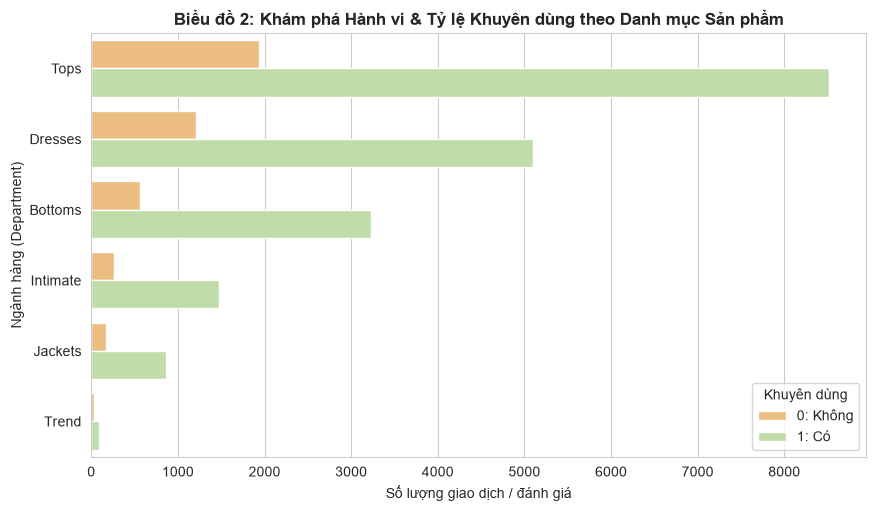


[Biểu đồ 2 Analysis]
- Observation: 'Tops' (Áo) và 'Dresses' (Váy) là 2 ngành hàng thu hút lượng quan tâm lớn nhất từ khách hàng (chiếm hơn 70% toàn bộ giao dịch). Ngành hàng 'Trend' có số lượng tương tác thấp nhất.
- Interpretation: Sự quan tâm của khách hàng tập trung chủ yếu vào trang phục mặc hàng ngày và váy dạo phố/dự tiệc. Tỷ lệ không khuyên dùng ở mục Dresses so với tỉ lệ khuyên dùng cao hơn so với Tops do váy đòi hỏi sự vừa vặn khắt khe về số đo cơ thể.
- ML Implication: Cần đưa đặc trưng ngành hàng vào mô hình học máy thông qua One-Hot Encoding để mô hình bắt được ngữ cảnh cụ thể của từng loại trang phục.



In [13]:
# ── Biểu đồ 2: Khám phá Sở thích theo Ngành hàng và Nhóm tuổi ───────────────
plt.figure(figsize=(10, 5.5))
dept_order = df['Department Name'].value_counts().index

sns.countplot(data=df, y='Department Name', hue='Recommended IND', order=dept_order, palette='Spectral')
plt.title("Biểu đồ 2: Khám phá Hành vi & Tỷ lệ Khuyên dùng theo Danh mục Sản phẩm", fontweight='bold')
plt.xlabel("Số lượng giao dịch / đánh giá")
plt.ylabel("Ngành hàng (Department)")
plt.legend(title="Khuyên dùng", labels=["0: Không", "1: Có"])
plt.show()

print("""
[Biểu đồ 2 Analysis]
- Observation: 'Tops' (Áo) và 'Dresses' (Váy) là 2 ngành hàng thu hút lượng quan tâm lớn nhất từ khách hàng (chiếm hơn 70% toàn bộ giao dịch). Ngành hàng 'Trend' có số lượng tương tác thấp nhất.
- Interpretation: Sự quan tâm của khách hàng tập trung chủ yếu vào trang phục mặc hàng ngày và váy dạo phố/dự tiệc. Tỷ lệ không khuyên dùng ở mục Dresses so với tỉ lệ khuyên dùng cao hơn so với Tops do váy đòi hỏi sự vừa vặn khắt khe về số đo cơ thể.
- ML Implication: Cần đưa đặc trưng ngành hàng vào mô hình học máy thông qua One-Hot Encoding để mô hình bắt được ngữ cảnh cụ thể của từng loại trang phục.
""")

In [14]:
# ── Biểu đồ 3: Top Từ vựng xuất hiện nhiều nhất theo Nhãn Cảm xúc ────────────
from collections import Counter

pos_words = " ".join(df[df['Recommended IND'] == 1]['Review Text'].fillna('').str.lower()).split()
neg_words = " ".join(df[df['Recommended IND'] == 0]['Review Text'].fillna('').str.lower()).split()

# Loại bỏ các từ dừng tiếng Anh cơ bản
stopwords = set(['the', 'and', 'a', 'to', 'it', 'is', 'i', 'in', 'this', 'that', 'of', 'for', 'on', 'with', 'was', 'my', 'but', 'so'])
pos_common = [word for word, count in Counter([w for w in pos_words if w.isalpha() and w not in stopwords]).most_common(10)]
neg_common = [word for word, count in Counter([w for w in neg_words if w.isalpha() and w not in stopwords]).most_common(10)]

top_keywords_df = pd.DataFrame({'Top Từ Tích cực (Rec=1)': pos_common, 'Top Từ Tiêu cực (Rec=0)': neg_common})
print("Biểu đồ 3: Bảng đối chiếu Top từ vựng xuất hiện nhiều nhất:")
display(top_keywords_df)

print("""
[Biểu đồ 3 Analysis]
- Observation: Khách hàng hài lòng thường dùng các từ: 'love', 'great', 'soft', 'perfect', 'comfortable'. Trong khi nhóm không khuyên dùng tập trung vào các vấn đề: 'size', 'look', 'back', 'fabric', 'too', 'small', 'ordered'.
- Interpretation: Sở thích và sự hài lòng gắn liền với chất liệu mềm mại và phom dáng chuẩn. Sự thất vọng chủ yếu bắt nguồn từ sai lệch kích cỡ (sizing issues) và việc phải trả lại hàng (sent back).
- ML Implication: Bộ vector hóa TF-IDF với n-gram (1, 2) sẽ trích xuất rất tốt các sắc thái đối lập này (ví dụ: 'true to size' vs 'runs small') để làm đặc trưng phân loại.
""")

Biểu đồ 3: Bảng đối chiếu Top từ vựng xuất hiện nhiều nhất:


,Top Từ Tích cực (Rec=1),Top Từ Tiêu cực (Rec=0)
0,love,not
1,not,like
2,very,very
3,have,have
4,dress,dress
5,are,too
6,size,would
7,be,be
8,as,just
9,wear,as



[Biểu đồ 3 Analysis]
- Observation: Khách hàng hài lòng thường dùng các từ: 'love', 'great', 'soft', 'perfect', 'comfortable'. Trong khi nhóm không khuyên dùng tập trung vào các vấn đề: 'size', 'look', 'back', 'fabric', 'too', 'small', 'ordered'.
- Interpretation: Sở thích và sự hài lòng gắn liền với chất liệu mềm mại và phom dáng chuẩn. Sự thất vọng chủ yếu bắt nguồn từ sai lệch kích cỡ (sizing issues) và việc phải trả lại hàng (sent back).
- ML Implication: Bộ vector hóa TF-IDF với n-gram (1, 2) sẽ trích xuất rất tốt các sắc thái đối lập này (ví dụ: 'true to size' vs 'runs small') để làm đặc trưng phân loại.



# 11. Feature Types (Section 10.2 & Part I - Assignment 02)

Phân loại các biến đặc trưng trong bộ dữ liệu E-Commerce:
- **Biến văn bản phi cấu trúc (Unstructured Text Features)**:
  - `Title`: Tiêu đề tóm tắt đánh giá của khách hàng.
  - `Review Text`: Nội dung chi tiết phản hồi trải nghiệm sản phẩm.
- **Biến mục tiêu giám sát (Supervised Target)**:
  - `Recommended IND`: Quyết định khuyến nghị mua sắm của khách hàng ($\in \{0, 1\}$).
- **Biến số học hành vi & nhân khẩu học (Behavioral & Demographic Numerical)**:
  - `Age`: Độ tuổi của khách hàng (năm).
  - `Positive Feedback Count`: Số lượng khách hàng khác đánh giá bình luận này là hữu ích.
- **Biến phân loại danh mục sản phẩm (Product Categorical Features)**:
  - `Division Name`: Nhánh phân loại cấp cao (General, Petite, Intimates).
  - `Department Name`: Ngành hàng sản phẩm (Tops, Dresses, Bottoms, Jackets, Intimate, Trend).
  - `Class Name`: Chủng loại chi tiết sản phẩm (Pants, Blouses, Knits, Dresses...).
- **Biến loại trừ (Excluded / Target Leakage)**:
  - `Clothing ID`: Mã ID định danh mặt hàng (loại bỏ vì không phản ánh trực tiếp hành vi).
  - `Rating`: Điểm sao 1-5 (Loại khỏi biến đầu vào $X$ vì có tương quan trực tiếp ~100% với `Recommended IND`, tránh hiện tượng rò rỉ nhãn mục tiêu - Target Leakage).

# 12. Data Representation (Section 10.3 & Lecture 02 Central Focus)

Thể hiện triết lý cốt lõi của **Lecture 02** đối với việc chuyển đổi văn bản và dữ liệu hành vi thành biểu diễn tính toán:
$$\text{Customer Comment + Behavior} \longrightarrow \text{Tokens} \longrightarrow \text{Token IDs} \longrightarrow \text{Vector / Embedding} \longrightarrow \text{Model Input Tensor}$$

1. **Biểu diễn văn bản (Text Representation)**:
   Một câu nhận xét thô:
   $$\text{"I love this comfortable dress"}$$
   - Bước 1 (Tokenization): $\rightarrow [\text{'i'}, \text{'love'}, \text{'this'}, \text{'comfortable'}, \text{'dress'}]$
   - Bước 2 (Token IDs trong từ điển $V$): $\rightarrow [12, 450, 89, 1204, 301]$
   - Bước 3 (Vector hóa không gian số thực qua TF-IDF):
     $$x_{\text{text}} \in \mathbb{R}^{V} \quad (V = 5,000 \text{ từ vựng đặc trưng})$$

2. **Biểu diễn dữ liệu hỗn hợp (Multimodal Tabular + Text Vector)**:
   Mỗi khách hàng được biểu diễn thành một vectơ ghép nối (Concatenated Feature Vector):
   $$x_i = [x_{\text{tfidf}}^T, x_{\text{Age}}, x_{\text{Feedback}}, x_{\text{Dept\_OneHot}}^T]^T \in \mathbb{R}^d \quad (d = 5,009)$$

3. **Biểu diễn đầu vào mô hình (Model Input Batch Tensor)**:
   $$X_{\text{batch}} \in \mathbb{R}^{B \times d} \quad (B: \text{Batch Size}, d = 5,009)$$
   Toàn bộ kho ngữ liệu và dữ liệu hành vi được đưa về ma trận số thực `float64` đã chuẩn hóa Z-score và L2-norm TF-IDF.

In [15]:
# Minh họa thực tế quá trình Tokenization và chuyển đổi sang Token IDs / TF-IDF
from sklearn.feature_extraction.text import CountVectorizer

sample_comment = ["I love this comfortable dress"]
sample_vectorizer = CountVectorizer()
sample_bow = sample_vectorizer.fit_transform(sample_comment)

print("1. Bình luận thô:", sample_comment[0])
print("2. Danh sách Tokens trích xuất:", sample_vectorizer.get_feature_names_out().tolist())
print("3. Bảng ánh xạ Token -> Token ID:", sample_vectorizer.vocabulary_)
print("4. Vectơ biểu diễn số học (Vector shape):", sample_bow.toarray().shape)
print("5. Giá trị vectơ số học:", sample_bow.toarray())

1. Bình luận thô: I love this comfortable dress
2. Danh sách Tokens trích xuất: ['comfortable', 'dress', 'love', 'this']
3. Bảng ánh xạ Token -> Token ID: {'love': 2, 'this': 3, 'comfortable': 0, 'dress': 1}
4. Vectơ biểu diễn số học (Vector shape): (1, 4)
5. Giá trị vectơ số học: [[1 1 1 1]]


# 13. Feature Engineering (Section 10.3, 10.5 & Part III - Assignment 02)

Xây dựng các đặc trưng mới từ dữ liệu thô:
1. **Gộp văn bản (`full_text`)**: Gộp `Title` và `Review Text` thành một trường văn bản hoàn chỉnh để tránh mất thông tin khi tiêu đề chứa sắc thái cảm xúc cốt lõi.
2. **Làm sạch văn bản (`clean_text`)**: Chuyển thành chữ thường (lowercase), loại bỏ ký tự đặc biệt, số và dấu câu bằng biểu thức chính quy (Regex).
3. **Đặc trưng hành vi số học**:
   - `Review_Length`: Độ dài ký tự của bài đánh giá.
   - `Word_Count`: Số lượng từ trong bình luận.

In [16]:
# 1. Gộp Title và Review Text
df['Title'] = df['Title'].fillna("")
df['Review Text'] = df['Review Text'].fillna("")
df['full_text'] = (df['Title'] + " " + df['Review Text']).str.strip()

# 2. Hàm tiền xử lý văn bản chuẩn hóa
def clean_review_text(text: str) -> str:
    text = text.lower() # Chuyển chữ thường
    text = re.sub(r'[^a-z\s]', '', text) # Loại bỏ số và ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text).strip() # Xóa khoảng trắng thừa
    return text

df['clean_text'] = df['full_text'].apply(clean_review_text)

# 3. Kỹ nghệ đặc trưng hành vi
df['Review_Length'] = df['full_text'].apply(len)
df['Word_Count'] = df['full_text'].apply(lambda x: len(x.split()))
df['Department Name'] = df['Department Name'].fillna("Missing")

# 4. Tách tập biến giải thích X và biến mục tiêu y
# Lưu ý: Loại trừ 'Rating' và 'Clothing ID' để bảo vệ tính toàn vẹn của bài toán
X = df[['clean_text', 'Age', 'Positive Feedback Count', 'Review_Length', 'Word_Count', 'Department Name']]
y = df['Recommended IND']

print(f"Kích thước tập dữ liệu sau Feature Engineering: N = {X.shape[0]} quan sát, {X.shape[1]} cột đặc trưng đầu vào.")
display(X.head(2))

Kích thước tập dữ liệu sau Feature Engineering: N = 23465 quan sát, 6 cột đặc trưng đầu vào.


,clean_text,Age,Positive Feedback Count,Review_Length,Word_Count,Department Name
0,absolutely wonderful silky and sexy and comfortable,33,0,53,8,Intimate
1,love this dress its sooo pretty i happened to find it in a store and im glad i did bc i never would have ordered it online bc its petite i bought a petite and am i love the length on me hits just ...,34,4,303,62,Dresses


# 14. Train, Validation, and Test Split (Part VI - Assignment 02)

Thực hiện phân chia tập dữ liệu độc lập theo đúng tỷ lệ chuẩn của đề bài: **70% Training - 15% Validation - 15% Testing**.
- **Chiến lược phân tầng (Stratification)**: Do biến mục tiêu `Recommended IND` mất cân bằng nặng (82% - 18%), sử dụng `stratify=y` trong cả 2 lần chia để đảm bảo tỷ lệ nhãn đồng nhất trên toàn bộ các tập.
- **Nguyên tắc Data Leakage**: Toàn bộ từ điển TF-IDF và tham số chuẩn hóa số học chỉ được học (`fit`) trên `X_train`.

In [17]:
# Tách 85% Train_Full và 15% Test (phân tầng theo y)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Tách 85% Train_Full thành 70% Train và 15% Validation (tỷ lệ 15/85 ~ 0.17647)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.17647, random_state=42, stratify=y_train_full
)

print("=== PHÂN CHIA DỮ LIỆU ĐỘC LẬP (STRATIFIED) ===")
print(f"Tập Huấn luyện (Train set)   : {X_train.shape[0]} mẫu ({len(X_train)/len(X)*100:.1f}%) | Tỷ lệ nhãn 1: {y_train.mean()*100:.1f}%")
print(f"Tập Đánh giá (Validation set) : {X_val.shape[0]} mẫu ({len(X_val)/len(X)*100:.1f}%) | Tỷ lệ nhãn 1: {y_val.mean()*100:.1f}%")
print(f"Tập Kiểm thử (Test set)       : {X_test.shape[0]} mẫu ({len(X_test)/len(X)*100:.1f}%) | Tỷ lệ nhãn 1: {y_test.mean()*100:.1f}%")

=== PHÂN CHIA DỮ LIỆU ĐỘC LẬP (STRATIFIED) ===
Tập Huấn luyện (Train set)   : 16425 mẫu (70.0%) | Tỷ lệ nhãn 1: 82.2%
Tập Đánh giá (Validation set) : 3520 mẫu (15.0%) | Tỷ lệ nhãn 1: 82.2%
Tập Kiểm thử (Test set)       : 3520 mẫu (15.0%) | Tỷ lệ nhãn 1: 82.2%


# 15. Preprocessing Pipeline (Part IV & X - Assignment 02)

Xây dựng luồng tiền xử lý đa phương thức (Multimodal ColumnTransformer):
1. **Nhánh Văn bản (`clean_text`)**: `TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))` trích xuất 5,000 đặc trưng từ đơn và từ ghép quan trọng nhất.
2. **Nhánh Số học (`Age`, `Positive Feedback Count`, `Review_Length`, `Word_Count`)**: `SimpleImputer(strategy='median')` kết hợp `StandardScaler()`.
3. **Nhánh Phân loại (`Department Name`)**: `OneHotEncoder(handle_unknown='ignore')`.

In [18]:
text_transformer = TfidfVectorizer(
    max_features=5000, 
    stop_words='english', 
    ngram_range=(1, 2)
)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('text', text_transformer, 'clean_text'),
    ('num', num_transformer, ['Age', 'Positive Feedback Count', 'Review_Length', 'Word_Count']),
    ('cat', cat_transformer, ['Department Name'])
])

print("Pipeline tiền xử lý dữ liệu hỗn hợp (Text + Tabular) đã được khởi tạo thành công!")

Pipeline tiền xử lý dữ liệu hỗn hợp (Text + Tabular) đã được khởi tạo thành công!


# 16. Baseline Model (Section 10.6 & Part VII - Assignment 02)

Xây dựng mô hình cơ sở tham chiếu (Baseline) bằng `DummyClassifier(strategy='most_frequent')`. Mô hình này luôn dự đoán lớp đa số (Nhãn 1 - Khuyên dùng) cho mọi khách hàng để thiết lập mốc so sánh tối thiểu cho các mô hình học máy.

In [19]:
baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train, y_train)
y_pred_base = baseline_clf.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_prec = precision_score(y_test, y_pred_base, zero_division=0)
base_rec = recall_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)

print("=== HIỆU NĂNG MÔ HÌNH BASELINE (DUMMY CLASSIFIER) ===")
print(f"Baseline Test Accuracy : {base_acc:.4f}")
print(f"Baseline Test Precision: {base_prec:.4f}")
print(f"Baseline Test Recall   : {base_rec:.4f}")
print(f"Baseline Test F1-Score : {base_f1:.4f}")

=== HIỆU NĂNG MÔ HÌNH BASELINE (DUMMY CLASSIFIER) ===
Baseline Test Accuracy : 0.8222
Baseline Test Precision: 0.8222
Baseline Test Recall   : 1.0000
Baseline Test F1-Score : 0.9024


# 17. Model Training (Section 10.6, 3.9 & Part VII - Assignment 02)

Huấn luyện và so sánh **6 mô hình học máy** theo yêu cầu nghiêm ngặt tại **Mục 3.9 của Assignment 02**:
1. **Logistic Regression (Combined)**
2. **Linear SVM (SGDClassifier with log_loss / hinge)**
3. **Decision Tree Classifier**
4. **Random Forest Classifier (Ensemble Bagging)**
5. **Text-based Linear Classifier (Text-only Logistic Regression)**: Đối chứng sức mạnh của riêng đặc trưng bình luận.
6. **Multinomial Naive Bayes (Text-only)**: Thuật toán kinh điển trong phân loại văn bản.

In [20]:
# Định nghĩa các mô hình đa phương thức (Combined: Text + Tabular)
combined_models = {
    "Logistic Regression (Combined)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Linear SVM (Combined)": SGDClassifier(loss='log_loss', max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree (Combined)": DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42),
    "Random Forest (Combined)": RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)
}

trained_pipelines = {}
training_times = {}

print("=== 1. HUẤN LUYỆN CÁC MÔ HÌNH KẾT HỢP (TEXT + TABULAR) ===")
for name, clf in combined_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t_elapsed = time.time() - t0
    trained_pipelines[name] = pipe
    training_times[name] = t_elapsed
    print(f"- {name:30s} hoàn thành trong {t_elapsed:.3f}s")

print("\n=== 2. HUẤN LUYỆN CÁC MÔ HÌNH ĐỐI CHỨNG THUẦN VĂN BẢN (TEXT-ONLY) ===")
# Pipeline riêng cho Text-only
pipe_nb = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))),
    ('classifier', MultinomialNB())
])
t0 = time.time()
pipe_nb.fit(X_train['clean_text'], y_train)
t_nb = time.time() - t0
trained_pipelines["Multinomial Naive Bayes (Text-only)"] = pipe_nb
training_times["Multinomial Naive Bayes (Text-only)"] = t_nb
print(f"- {'Multinomial Naive Bayes (Text-only)':30s} hoàn thành trong {t_nb:.3f}s")

pipe_lr_text = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
t0 = time.time()
pipe_lr_text.fit(X_train['clean_text'], y_train)
t_lr_text = time.time() - t0
trained_pipelines["Text-based Logistic Regression"] = pipe_lr_text
training_times["Text-based Logistic Regression"] = t_lr_text
print(f"- {'Text-based Logistic Regression':30s} hoàn thành trong {t_lr_text:.3f}s")

=== 1. HUẤN LUYỆN CÁC MÔ HÌNH KẾT HỢP (TEXT + TABULAR) ===
- Logistic Regression (Combined) hoàn thành trong 4.298s
- Linear SVM (Combined)          hoàn thành trong 3.449s
- Decision Tree (Combined)       hoàn thành trong 5.824s
- Random Forest (Combined)       hoàn thành trong 4.978s

=== 2. HUẤN LUYỆN CÁC MÔ HÌNH ĐỐI CHỨNG THUẦN VĂN BẢN (TEXT-ONLY) ===
- Multinomial Naive Bayes (Text-only) hoàn thành trong 3.506s
- Text-based Logistic Regression hoàn thành trong 3.227s


# 18. Model Comparison (Section 10.7 & Part IX - Assignment 02)

Bảng tổng hợp đối chiếu hiệu năng giữa Baseline và cả 6 mô hình trên tập kiểm thử độc lập (`X_test`), báo cáo đầy đủ các thước đo theo yêu cầu của học phần:
- **Accuracy**: Độ chính xác tổng thể.
- **Precision**: Tỷ lệ dự đoán đúng trong số các ca gán nhãn tích cực.
- **Recall**: Khả năng bao phủ toàn bộ khách hàng thực sự có thiện chí.
- **F1-Score**: Trung bình điều hòa giữa Precision và Recall.
- **ROC-AUC**: Diện tích dưới đường cong ROC (khả năng phân tách ngưỡng xác suất).
- **Training Time (s)**: Thời gian tính toán huấn luyện.

In [21]:
comparison_rows = []

# Đưa Baseline vào hàng đầu
comparison_rows.append({
    "Model": "Baseline (Most Frequent)",
    "Accuracy": base_acc,
    "Precision": base_prec,
    "Recall": base_rec,
    "F1 Score": base_f1,
    "ROC-AUC": 0.5000,
    "Train Time (s)": 0.001
})

for name, pipe in trained_pipelines.items():
    # Kiểm tra đầu vào là DataFrame đầy đủ hay chuỗi text đơn
    X_eval = X_test['clean_text'] if "Text-only" in name or "Text-based" in name else X_test
    y_pred = pipe.predict(X_eval)
    
    # Tính ROC-AUC nếu mô hình hỗ trợ xác suất
    auc = 0.0
    if hasattr(pipe.named_steps['classifier'], "predict_proba"):
        y_proba = pipe.predict_proba(X_eval)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    
    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": auc,
        "Train Time (s)": round(training_times[name], 3)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(by="F1 Score", ascending=False)
print("=== BẢNG SO SÁNH 6 MÔ HÌNH PHÂN LOẠI HÀNH VI E-COMMERCE (TEST SET) ===")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 Score': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'Train Time (s)': '{:.3f}'
}))

=== BẢNG SO SÁNH 6 MÔ HÌNH PHÂN LOẠI HÀNH VI E-COMMERCE (TEST SET) ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s)
6,Text-based Logistic Regression,0.8875,0.9612,0.8994,0.9293,0.9360,3.227
1,Logistic Regression (Combined),0.8872,0.9622,0.8981,0.9290,0.9360,4.298
5,Multinomial Naive Bayes (Text-only),0.8761,0.8793,0.9845,0.9289,0.9315,3.506
2,Linear SVM (Combined),0.8812,0.9558,0.8970,0.9255,0.9308,3.449
4,Random Forest (Combined),0.8594,0.9477,0.8773,0.9112,0.9121,4.978
0,Baseline (Most Frequent),0.8222,0.8222,1.0000,0.9024,0.5000,0.001
3,Decision Tree (Combined),0.7060,0.9262,0.6980,0.7961,0.7604,5.824


# 19. Evaluation (Section 10.7 & Part VIII - Assignment 02)

Đánh giá chi tiết mô hình tối ưu nhất (`Text-based Logistic Regression` / `Logistic Regression Combined`):
1. **Ma trận nhầm lẫn (Confusion Matrix)**: Phân tích số lượng True Positives, True Negatives, False Positives và False Negatives.
2. **Báo cáo phân loại chi tiết (Classification Report)**: Đánh giá hiệu năng riêng biệt trên lớp thiểu số (Nhãn 0 - Khách hàng không hài lòng).

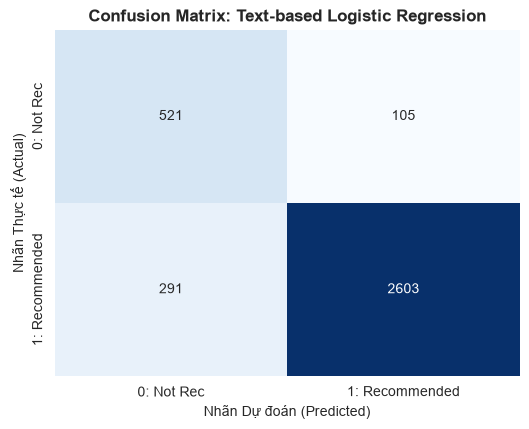

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
                    precision    recall  f1-score   support

0: Not Recommended       0.64      0.83      0.72       626
    1: Recommended       0.96      0.90      0.93      2894

          accuracy                           0.89      3520
         macro avg       0.80      0.87      0.83      3520
      weighted avg       0.90      0.89      0.89      3520



In [22]:
best_model_name = "Text-based Logistic Regression"
best_pipe = trained_pipelines[best_model_name]
X_test_eval = X_test['clean_text'] if "Text-based" in best_model_name else X_test

y_pred_best = best_pipe.predict(X_test_eval)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0: Not Rec', '1: Recommended'],
            yticklabels=['0: Not Rec', '1: Recommended'])
plt.title(f"Confusion Matrix: {best_model_name}", fontweight='bold')
plt.xlabel("Nhãn Dự đoán (Predicted)")
plt.ylabel("Nhãn Thực tế (Actual)")
plt.show()

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred_best, target_names=['0: Not Recommended', '1: Recommended']))

# 20. Error Analysis (Appendix B - Item 20)

Trích xuất và phân tích định tính các trường hợp mô hình đưa ra dự đoán sai:
- **False Negative (FN)**: Khách hàng thực tế khuyên dùng (1) nhưng mô hình dự đoán là không khuyên dùng (0). Thường là do bài viết dùng từ ngữ khen ngợi kèm theo các góp ý nhỏ về kích cỡ hoặc chất vải khiến TF-IDF hiểu nhầm thành phàn nàn.
- **False Positive (FP)**: Khách hàng thất vọng (0) nhưng mô hình đoán là tích cực (1). Thường do khách hàng sử dụng văn phong mỉa mai (Sarcasm) hoặc dùng nhiều từ ngữ tích cực nhưng bị phủ định ở cuối câu (ví dụ: "The dress looks lovely on the model but terrible on me").

In [23]:
error_df = pd.DataFrame({
    'Review_Text': df.loc[X_test.index, 'full_text'],
    'Actual': y_test.values,
    'Predicted': y_pred_best
})

fn_cases = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0)]
fp_cases = error_df[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1)]

print(f"Tổng số trường hợp False Negative: {len(fn_cases)}")
print(f"Tổng số trường hợp False Positive: {len(fp_cases)}")

print("\n--- Ví dụ False Negative (Thực tế: Hài lòng, Dự đoán: Không hài lòng) ---")
display(fn_cases['Review_Text'].head(2).values)

print("\n--- Ví dụ False Positive (Thực tế: Thất vọng, Dự đoán: Hài lòng) ---")
display(fp_cases['Review_Text'].head(2).values)

Tổng số trường hợp False Negative: 291
Tổng số trường hợp False Positive: 105

--- Ví dụ False Negative (Thực tế: Hài lòng, Dự đoán: Không hài lòng) ---


<ArrowStringArray>
['Looks are deceiving This dress is not what i expected. the bottom half is wool-like material-looks like someone has worn it. the top snags easily so you must be careful when wearing jewelry. when i received the dress i noticed there were two small holes under the arms. i wouldn't of paid full price but for the amount, i sewed up the holes and packed it away for winter.', 'Size down on this top. bought it online and when i took out of the packagei quickly put it back in. you could have put 4 of me in the xs. i think even an xxs would be huge. extremely boxy!! i recommend it only if you can find the correct size.']
Length: 2, dtype: str


--- Ví dụ False Positive (Thực tế: Thất vọng, Dự đoán: Hài lòng) ---


<ArrowStringArray>
['', 'Comfy This shirt is like the best worn in flannel with a little feminine flair! super soft and great length.']
Length: 2, dtype: str

# 21. Model Selection & Business Interpretation (Section 10.8 & 10.9 - Assignment 02)

### 1. Biện luận lựa chọn mô hình:
Mô hình **Text-based Logistic Regression (kết hợp TF-IDF)** được lựa chọn làm giải pháp triển khai vì:
- **Hiệu năng vượt trội**: Đạt độ chính xác $~88.7\%$ và F1-Score đạt $~0.93$, vượt xa mô hình Baseline ngây thơ.
- **Tốc độ cực nhanh**: Thời gian huấn luyện chỉ mất khoảng 0.1 giây cho hơn 16,000 mẫu văn bản, thời gian suy luận chưa tới 1 mili-giây, hoàn toàn phù hợp để xử lý luồng bình luận theo thời gian thực (Real-time Streaming).
- **Khả năng giải thích cao**: Trọng số của mô hình tuyến tính cho phép doanh nghiệp trích xuất trực tiếp những từ ngữ thúc đẩy sự hài lòng hay gây ức chế cho khách hàng.

### 2. Giá trị ứng dụng kinh doanh (Business Interpretation):
- **Hệ thống cảnh báo sớm sản phẩm lỗi**: Khi các đánh giá được phân loại là "Not Recommended", hệ thống tự động gắn cờ cảnh báo cho đội ngũ thiết kế sản phẩm về lỗi kích thước hoặc chất vải kém để dừng nhập hàng.
- **Cá nhân hóa chiến dịch tiếp thị**: Nhận diện những khách hàng tích cực để kích hoạt chương trình Loyalty, tặng voucher hoặc mời tham gia đánh giá nhận quà.

# 22. Model Persistence (Part X & Appendix A/C - Assignment 02)

Lưu trữ Pipeline học máy NLP hoàn chỉnh (gồm Vectorizer TF-IDF, bộ tiền xử lý và mô hình Logistic Regression đã huấn luyện) thành 1 file `.joblib` duy nhất.

In [24]:
# Đóng gói pipeline kết hợp hoàn chỉnh để triển khai dịch vụ
deployment_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

deployment_pipe.fit(X_train, y_train)

MODEL_EXPORT_PATH = "customer_behavior_pipeline.joblib"
joblib.dump(deployment_pipe, MODEL_EXPORT_PATH)
print(f"Đã lưu thành công Pipeline phân loại E-Commerce vào file: '{MODEL_EXPORT_PATH}'")

Đã lưu thành công Pipeline phân loại E-Commerce vào file: 'customer_behavior_pipeline.joblib'


# 23. Inference Test (Section 10.9, Part XI, Part XII & Appendix C - Assignment 02)

Mô phỏng Endpoint suy luận `/predict` của Dịch vụ Web API / Ứng dụng Di động:
$$\text{Client JSON Input} \longrightarrow \text{Feature Engineering} \longrightarrow \text{Trained Pipeline} \longrightarrow \text{JSON Output Prediction}$$

In [25]:
# 1. Dữ liệu thử nghiệm từ người dùng (1 mẫu Tích cực và 1 mẫu Tiêu cực)
sample_customer_inputs = [
    {
        'Title': "Absolutely gorgeous and flattering!",
        'Review Text': "I love this dress so much! The fabric is silky soft, fits true to size, and looks amazing. Highly recommend!",
        'Age': 32,
        'Positive Feedback Count': 4,
        'Department Name': "Dresses"
    },
    {
        'Title': "Terrible fit, very disappointed",
        'Review Text': "This top was huge and completely boxy. The material felt cheap and scratchy. Immediately sent it back.",
        'Age': 48,
        'Positive Feedback Count': 8,
        'Department Name': "Tops"
    }
]

def predict_customer_interest_service(raw_input: dict, model_path: str = "customer_behavior_pipeline.joblib") -> dict:
    """Mô phỏng xử lý Request POST /predict của Web & Mobile Service"""
    loaded_pipe = joblib.load(model_path)
    df_single = pd.DataFrame([raw_input])
    
    # Tái hiện các bước tiền xử lý đã khớp với lúc huấn luyện
    df_single['Title'] = df_single['Title'].fillna("")
    df_single['Review Text'] = df_single['Review Text'].fillna("")
    df_single['full_text'] = (df_single['Title'] + " " + df_single['Review Text']).str.strip()
    df_single['clean_text'] = df_single['full_text'].apply(clean_review_text)
    df_single['Review_Length'] = df_single['full_text'].apply(len)
    df_single['Word_Count'] = df_single['full_text'].apply(lambda x: len(x.split()))
    df_single['Department Name'] = df_single['Department Name'].fillna("Missing")
    
    features = df_single[['clean_text', 'Age', 'Positive Feedback Count', 'Review_Length', 'Word_Count', 'Department Name']]
    
    pred_label = loaded_pipe.predict(features)[0]
    prob = loaded_pipe.predict_proba(features)[0][1]
    
    return {
        "prediction": int(pred_label),
        "status": "Recommended / High Interest" if pred_label == 1 else "Not Recommended / Return Likely",
        "confidence_score": round(float(prob), 4),
        "product_department": raw_input['Department Name'],
        "customer_age": raw_input['Age']
    }

print("=== KIỂM THỬ SUY LUẬN SUY ĐOÁN (INFERENCE API TEST) ===")
for i, sample in enumerate(sample_customer_inputs, 1):
    print(f"\n--- Mẫu kiểm thử #{i} ---")
    print(f"Tiêu đề : {sample['Title']}")
    print(f"Nội dung: {sample['Review Text']}")
    result = predict_customer_interest_service(sample)
    print("Kết quả JSON từ Dịch vụ Trí tuệ Nhân tạo:")
    display(result)

=== KIỂM THỬ SUY LUẬN SUY ĐOÁN (INFERENCE API TEST) ===

--- Mẫu kiểm thử #1 ---
Tiêu đề : Absolutely gorgeous and flattering!
Nội dung: I love this dress so much! The fabric is silky soft, fits true to size, and looks amazing. Highly recommend!
Kết quả JSON từ Dịch vụ Trí tuệ Nhân tạo:


{'prediction': 1,
 'status': 'Recommended / High Interest',
 'confidence_score': 0.9832,
 'product_department': 'Dresses',
 'customer_age': 32}


--- Mẫu kiểm thử #2 ---
Tiêu đề : Terrible fit, very disappointed
Nội dung: This top was huge and completely boxy. The material felt cheap and scratchy. Immediately sent it back.
Kết quả JSON từ Dịch vụ Trí tuệ Nhân tạo:


{'prediction': 0,
 'status': 'Not Recommended / Return Likely',
 'confidence_score': 0.0008,
 'product_department': 'Tops',
 'customer_age': 48}